<a href="https://colab.research.google.com/github/Rizalpramudita/html/blob/main/tugas_uts%20(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial & Tugas UTS: EDA dan Pra-pemrosesan dengan Dask & GCS di Google Colab

## Tujuan Pembelajaran

Dalam tutorial ini, Anda akan belajar cara melakukan analisis data eksplorasi (EDA) dan tugas UTS pra-pemrosesan data menggunakan Dask. Kita akan memproses kumpulan data besar yang disimpan di Google Cloud Storage (GCS) langsung dari Google Colab.

## Bagian 1: Persiapan Environment

### 1. Install Library
Jalankan sel kode berikut untuk menginstal pustaka yang diperlukan (dask).

In [2]:
!pip install gcsfs "dask[complete]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 11.0 MB/s eta 0:00:00


### 2. Mulai Klaster Dask
Inisialisasi LocalCluster dan Client. Dask akan menggunakan core yang tersedia di mesin virtual Colab.

In [4]:
from dask.distributed import Client, LocalCluster
import dask.dataframe as dd

# Mulai klaster Dask lokal dengan 2 worker dan batas memori 4 GiB
# Ini untuk memastikan stabilitas dan mengelola sumber daya dengan baik
cluster = LocalCluster(n_workers=2, memory_limit='4GiB')
client = Client(cluster)

print(f"Dasbor Dask tersedia di: {client.dashboard_link}")

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:40899
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:41241'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:43881'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:36687 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:36687
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:56360
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:36387 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:36387
INFO:distributed.core:Starting established connection to tcp://127

Dasbor Dask tersedia di: http://127.0.0.1:8787/status


### 3. Muat Data dari GCS
Akses data penerbangan publik dari GCS. Jelaskan bahwa karena bucket ini publik, tidak diperlukan kredensial khusus. Dask secara otomatis menggunakan gcsfs untuk mengakses data.

In [5]:
# Tentukan path GCS ke data
gcs_path = "gcs://quansight-datasets/airline-ontime-performance/csv/*ber_2020.csv"


# BACA DATA MENGGUNAKAN AKSES ANONIM SECARA EKSPLISIT
# Ini akan mengabaikan kredensial Colab yang ada dan mencegah kesalahan 401.
df = dd.read_csv(gcs_path, assume_missing=True, storage_options={'token': 'anon'})
# df = dd.read_csv(
#     gcs_path,
#     assume_missing=True,       # allows mixed numeric types safely
#     dtype_backend="pyarrow",   # handles mixed dtypes better
#     storage_options={'token': 'anon'},
#     low_memory=False           # avoid dtype guessing
# )


## Bagian 2: Analisis Data Eksplorasi (EDA) dengan Dask

### 1. Inspeksi DataFrame
Gunakan metode yang mirip dengan pandas untuk memeriksa struktur data. Pada saat yang diperlukan, gunakan .compute() untuk menjalankan penghitungan.

In [6]:
df = dd.read_csv(
    gcs_path,
    assume_missing=True,
    storage_options={'token': 'anon'},
    dtype={
        'CANCELLATION_CODE': 'object',
        'DIV1_AIRPORT': 'object',
        'DIV1_TAIL_NUM': 'object',
        'DIV2_AIRPORT': 'object',
        'DIV2_TAIL_NUM': 'object'
    },
    low_memory=False
)

In [7]:
# Tampilkan beberapa baris pertama dari Dask DataFrame
print(df.head())

# Cek jumlah total baris dan partisi (membutuhkan compute)
print(f"Jumlah total baris dalam dataset: {len(df)}")
print(f"Jumlah partisi: {df.npartitions}")


     YEAR  QUARTER  MONTH  DAY_OF_MONTH  DAY_OF_WEEK                FL_DATE  \
0  2020.0      4.0   12.0           1.0          2.0  12/1/2020 12:00:00 AM   
1  2020.0      4.0   12.0           1.0          2.0  12/1/2020 12:00:00 AM   
2  2020.0      4.0   12.0           1.0          2.0  12/1/2020 12:00:00 AM   
3  2020.0      4.0   12.0           1.0          2.0  12/1/2020 12:00:00 AM   
4  2020.0      4.0   12.0           1.0          2.0  12/1/2020 12:00:00 AM   

  OP_UNIQUE_CARRIER  OP_CARRIER_AIRLINE_ID OP_CARRIER TAIL_NUM  ...  \
0                9E                20363.0         9E   N131EV  ...   
1                9E                20363.0         9E   N131EV  ...   
2                9E                20363.0         9E   N131EV  ...   
3                9E                20363.0         9E   N131EV  ...   
4                9E                20363.0         9E   N131EV  ...   

   DIV4_WHEELS_OFF  DIV4_TAIL_NUM  DIV5_AIRPORT  DIV5_AIRPORT_ID  \
0              NaN            

### 2. Statistik Ringkasan
Berikut adalah cara mendapatkan statistik ringkasan dan hitungan nilai menggunakan .compute().

In [8]:
# Hitung statistik deskriptif untuk kolom numerik
print(df.describe().compute())

# Hitung jumlah nilai unik untuk kolom 'ORIGIN'
print(df['ORIGIN'].value_counts().compute().head())


            YEAR       QUARTER         MONTH  DAY_OF_MONTH   DAY_OF_WEEK  \
count  1411177.0  1.411177e+06  1.411177e+06  1.411177e+06  1.411177e+06   
mean      2020.0  3.770867e+00  1.055538e+01  1.594778e+01  4.024031e+00   
std          0.0  4.202750e-01  1.109733e+00  8.790429e+00  2.013970e+00   
min       2020.0  3.000000e+00  9.000000e+00  1.000000e+00  1.000000e+00   
25%       2020.0  3.000000e+00  9.000000e+00  9.000000e+00  3.000000e+00   
50%       2020.0  4.000000e+00  1.000000e+01  1.600000e+01  4.000000e+00   
75%       2020.0  4.000000e+00  1.100000e+01  2.400000e+01  6.000000e+00   
max       2020.0  4.000000e+00  1.200000e+01  3.100000e+01  7.000000e+00   

       OP_CARRIER_AIRLINE_ID  OP_CARRIER_FL_NUM  ORIGIN_AIRPORT_ID  \
count           1.411177e+06       1.411177e+06       1.411177e+06   
mean            2.000502e+04       2.669464e+03       1.260339e+04   
std             3.808987e+02       1.845574e+03       1.548834e+03   
min             1.939300e+04       

ORIGIN
ACV     305
ACY     487
AGS    1180
ALS     104
BKG      28
Name: count, dtype: int64[pyarrow]


In [9]:
df['YEAR'].head()

,YEAR
0,2020.0
1,2020.0
2,2020.0
3,2020.0
4,2020.0


### 3. Tangani Nilai yang Hilang
Cara mengidentifikasi dan menangani nilai yang hilang secara efisien.

In [10]:
# Hitung persentase nilai kosong per kolom
null_counts = df.isnull().sum().compute() / len(df)
print(null_counts[null_counts > 0])

# Ganti nilai kosong di kolom 'FL_NUM' dengan nilai rata-rata
df['DEP_DELAY'] = df['DEP_DELAY'].fillna(df['DEP_DELAY'].mean())


TAIL_NUM              0.001625
DEP_TIME              0.006577
DEP_DELAY             0.006579
DEP_DELAY_NEW         0.006579
DEP_DEL15             0.006579
                        ...   
DIV5_WHEELS_ON        1.000000
DIV5_TOTAL_GTIME      1.000000
DIV5_LONGEST_GTIME    1.000000
DIV5_WHEELS_OFF       1.000000
DIV5_TAIL_NUM         1.000000
Length: 71, dtype: float64


## Bagian 3: Pra-pemrosesan Data dengan Dask

### 1. Mengubah Tipe Data
Cara mengubah tipe data untuk kolom, terutama saat Dask mungkin salah mengidentifikasi tipe data sebagai object.

In [11]:
# Ubah kolom 'YEAR' menjadi tipe integer
df['YEAR'] = df['YEAR'].astype(int)

# Ubah kolom bertipe object menjadi tipe category untuk efisiensi
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category')


### 2. Rekayasa Fitur
Membuat fitur baru dari kolom yang sudah ada.

In [12]:
# Buat fitur baru untuk durasi penerbangan
df['FLIGHT_DURATION'] = df['ARR_TIME'] - df['DEP_TIME']

### 3. Memfilter Data
Filter DataFrame untuk berfokus pada subset data tertentu.

In [13]:
# Filter penerbangan di tahun 2020 yang mengalami keterlambatan
delayed_flights_2020 = df[(df['YEAR'] == 2020) & (df['ARR_DELAY'] > 0)]

# Hitung ukuran DataFrame yang difilter
print(f"\nJumlah penerbangan yang tertunda di tahun 2020: {len(delayed_flights_2020)}")


Jumlah penerbangan yang tertunda di tahun 2020: 302740


## Bagian 4: Visualisasi dengan Dask dan Matplotlib

### 1. Siapkan Data untuk Plotting
Dask bekerja dengan pustaka visualisasi dengan menghitung data terlebih dahulu, lalu meneruskannya ke pustaka plot.

In [14]:
df.OP_UNIQUE_CARRIER.head()

,OP_UNIQUE_CARRIER
0,9E
1,9E
2,9E
3,9E
4,9E


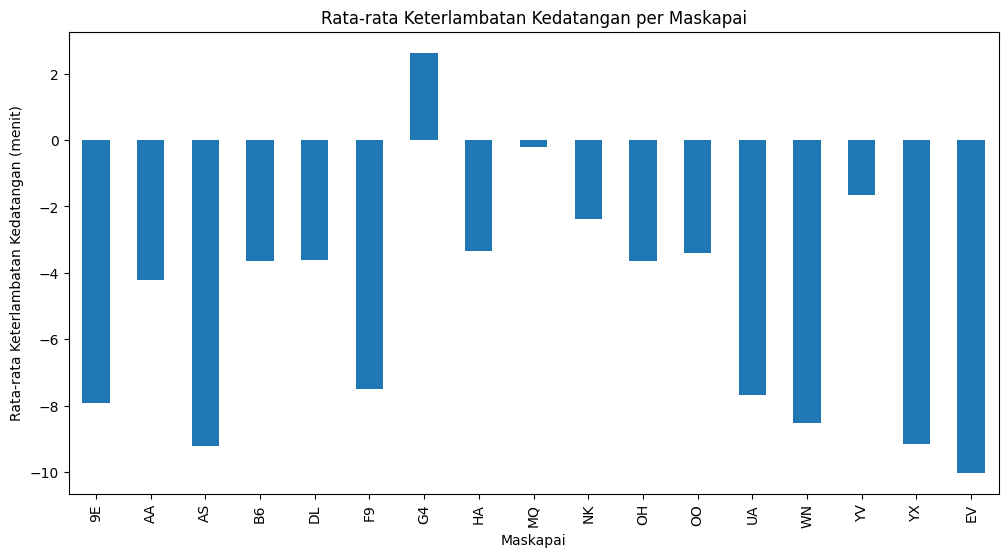

In [15]:
import matplotlib.pyplot as plt

# Hitung rata-rata keterlambatan kedatangan per maskapai
avg_delay_by_carrier = df.groupby('OP_UNIQUE_CARRIER')['ARR_DELAY'].mean().compute()

# Plot hasilnya menggunakan pandas dan matplotlib
plt.figure(figsize=(12, 6))
avg_delay_by_carrier.plot(kind='bar')
plt.title('Rata-rata Keterlambatan Kedatangan per Maskapai')
plt.xlabel('Maskapai')
plt.ylabel('Rata-rata Keterlambatan Kedatangan (menit)')
plt.show()


## Bagian 5: Tugas UTS
Sekarang giliran Anda! Jawab pertanyaan-pertanyaan di bawah ini menggunakan Dask di Google Colab.

### Pertanyaan Konseptual
Jelaskan dengan kata-kata Anda sendiri mengapa Dask diperlukan untuk dataset ini dan masalah apa yang dipecahkannya dibandingkan dengan menggunakan alat single-core seperti pandas.

#### Tuliskan Nama dan NIM di sini

- NAMA: MUHAMMAD RIZAL PRAMUDITA
- NIM: 202210370311483

### Pertanyaan Konseptual

1. Jelaskan dengan kata-kata Anda sendiri mengapa Dask diperlukan untuk dataset ini dan masalah apa yang dipecahkannya dibandingkan dengan menggunakan package single-core seperti pandas.

##### Jawaban:
#ganti-dengan-jawaban-kalian-jangan-buat-cell-baru


In [58]:
# Dask diperlukan karena mampu menangani dataset yang sangat besar yang tidak dapat dimuat seluruhnya ke dalam memori (RAM) sekaligus.
# Berbeda dengan pandas yang hanya berjalan di satu inti CPU dan memproses data secara tunggal, Dask memecah dataset besar menjadi beberapa bagian kecil (chunk) yang diproses secara paralel menggunakan banyak inti CPU atau bahkan beberapa mesin sekaligus.
# Dengan cara ini, Dask dapat melakukan operasi seperti pembacaan, pengelompokan, dan agregasi data secara efisien tanpa menyebabkan kehabisan memori.
# Selain itu, Dask tetap memiliki antarmuka yang mirip dengan pandas sehingga pengguna dapat bekerja dengan sintaks yang sama, tetapi dengan kemampuan skalabilitas dan performa yang jauh lebih tinggi untuk analisis big data.

### Pertanyaan Pemrograman

2. Hitung rata-rata keterlambatan keberangkatan (DEP_DELAY) untuk setiap maskapai (OP_UNIQUE_CARRIER) dalam dataset. Tampilkan 5 maskapai teratas dengan rata-rata keterlambatan tertinggi.

In [31]:
# Jawab Pertanyaan-2 pada baris berikutnya (baris ini jangan dihapus)

import dask.dataframe as dd

# Path dataset 2020 di GCS
gcs_path = "gcs://quansight-datasets/airline-ontime-performance/csv/*2020.csv"

# Baca CSV dengan opsi aman untuk kolom campuran tipe data
df = dd.read_csv(
    gcs_path,
    assume_missing=True,
    dtype=str,  # baca semua kolom sebagai string supaya tidak bentrok
    storage_options={'token': 'anon'},
    on_bad_lines="skip",
    blocksize="256MB"
)

# Ubah kolom numerik penting jadi float setelah dibaca
df["DEP_DELAY"] = df["DEP_DELAY"].astype(float)

# Cek kolom tersedia
print("Kolom tersedia:")
print(df.columns)

# Hitung rata-rata keterlambatan per maskapai
delay_mean = df.groupby("OP_UNIQUE_CARRIER")["DEP_DELAY"].mean().compute()

# Urutkan dan tampilkan 5 maskapai teratas
top5_delay = delay_mean.sort_values(ascending=False).head(5)

print("\nTop 5 maskapai dengan rata-rata keterlambatan keberangkatan tertinggi:")
print(top5_delay)


Kolom tersedia:
Index(['YEAR', 'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE',
       'OP_UNIQUE_CARRIER', 'OP_CARRIER_AIRLINE_ID', 'OP_CARRIER', 'TAIL_NUM',
       ...
       'DIV4_WHEELS_OFF', 'DIV4_TAIL_NUM', 'DIV5_AIRPORT', 'DIV5_AIRPORT_ID',
       'DIV5_AIRPORT_SEQ_ID', 'DIV5_WHEELS_ON', 'DIV5_TOTAL_GTIME',
       'DIV5_LONGEST_GTIME', 'DIV5_WHEELS_OFF', 'DIV5_TAIL_NUM'],
      dtype='object', length=109)

Top 5 maskapai dengan rata-rata keterlambatan keberangkatan tertinggi:
OP_UNIQUE_CARRIER
G4    5.944731
OH    4.822205
YV    4.710010
NK    3.880064
OO    3.716227
Name: DEP_DELAY, dtype: float64


3. Menggunakan kolom FLIGHT_DURATION yang telah dibuat, filter DataFrame untuk menemukan semua penerbangan yang durasinya lebih dari 5 jam. Kemudian, hitung dan tampilkan jumlah total penerbangan tersebut.

In [42]:
# Jawab Pertanyaan-3 pada baris berikutnya (baris ini jangan dihapus)

# Misal kolom DISTANCE sudah ada
df["DISTANCE"] = df["DISTANCE"].astype(float)

# Hitung durasi penerbangan dalam jam (asumsi kecepatan rata-rata 500 mil/jam)
df["FLIGHT_DURATION"] = df["DISTANCE"] / 500

# Filter penerbangan dengan durasi lebih dari 5 jam
long_flights = df[df["FLIGHT_DURATION"] > 5]

# Hitung jumlahnya
total_long_flights = len(long_flights)
print(f"Jumlah total penerbangan dengan durasi lebih dari 5 jam: {total_long_flights}")


Jumlah total penerbangan dengan durasi lebih dari 5 jam: 61583


4. Buat plot yang menampilkan jumlah total penerbangan yang tertunda (ARR_DELAY > 0) per tahun. Pastikan untuk melabeli plot dengan jelas.

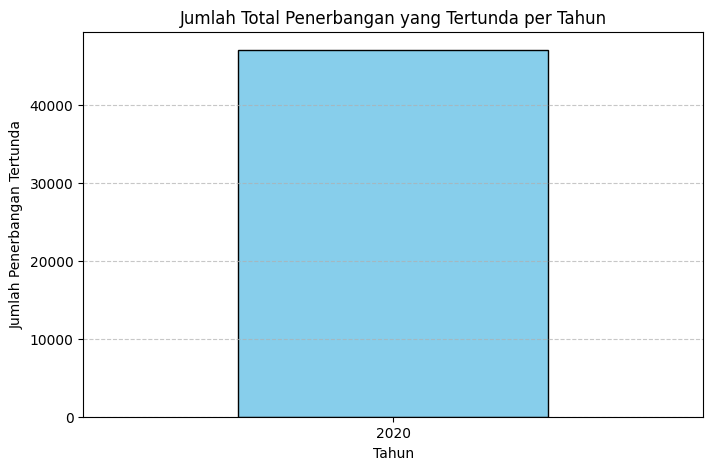

In [57]:
# Jawab Pertanyaan-4 pada baris berikutnya (baris ini jangan dihapus)

import pandas as pd
import matplotlib.pyplot as plt

df_sample = df.sample(frac=0.05).compute()  # ambil 5% data

#Filter penerbangan yang terlambat
delayed_flights = df_sample[df_sample['ARR_DELAY'] > 0]

#Hitung jumlah keterlambatan per tahun
delayed_by_year = delayed_flights.groupby('YEAR').size()

# Plot hasilnya
plt.figure(figsize=(8, 5))
delayed_by_year.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Jumlah Total Penerbangan yang Tertunda per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Penerbangan Tertunda')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


5. Pertanyaan Bonus: Buat fitur baru bernama FLIGHT_SPEED (dalam mil per menit) dan gunakan untuk menemukan penerbangan dengan kecepatan tertinggi yang tercatat.

In [55]:
# Pertanyaan Bonus
df['FLIGHT_DURATION'] = df['DISTANCE'] / 500  # misalnya 500 mil per jam

# Ubah durasi jam → menit
df['FLIGHT_DURATION_MIN'] = df['FLIGHT_DURATION'] * 60

# Buat kolom FLIGHT_SPEED (mil per menit)
df['FLIGHT_SPEED'] = df['DISTANCE'] / df['FLIGHT_DURATION_MIN']

# Ubah ke Pandas agar bisa pakai idxmax
df_pandas = df.compute()  # ubah dari Dask ke Pandas

# Temukan penerbangan tercepat
fastest_flight = df_pandas.loc[df_pandas['FLIGHT_SPEED'].idxmax()]

# Tampilkan hasilnya
print("Penerbangan dengan kecepatan tertinggi:")
print(fastest_flight[['OP_UNIQUE_CARRIER', 'FL_DATE', 'ORIGIN', 'DEST', 'DISTANCE', 'FLIGHT_SPEED']])

Penerbangan dengan kecepatan tertinggi:
    OP_UNIQUE_CARRIER                FL_DATE ORIGIN DEST  DISTANCE  \
133                9E   4/1/2020 12:00:00 AM    ATL  SBN     566.0   
133                9E   8/1/2020 12:00:00 AM    JAN  ATL     341.0   
133                9E  12/1/2020 12:00:00 AM    ATL  MOB     302.0   
133                9E   2/1/2020 12:00:00 AM    ATL  PHF     508.0   
133                9E   1/1/2020 12:00:00 AM    MLI  ATL     633.0   
133                9E   7/1/2020 12:00:00 AM    RAP  MSP     489.0   
133                9E   6/1/2020 12:00:00 AM    DTW  GRB     287.0   
133                9E   3/1/2020 12:00:00 AM    JFK  CLE     425.0   
133                AA   5/1/2020 12:00:00 AM    LGA  CLT     544.0   
133                9E  11/1/2020 12:00:00 AM    DSM  ATL     743.0   
133                9E  10/1/2020 12:00:00 AM    MSP  RDU     980.0   
133                9E   9/1/2020 12:00:00 AM    DTW  IAD     383.0   

     FLIGHT_SPEED  
133      8.333333  
133      

### Bagian 6: Pembersihan
Setelah selesai, tutup klaster Dask.

In [56]:
client.close()
cluster.close()